In [2]:
import os
import random
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt

from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

from transformers import AutoTokenizer, AutoModelForSequenceClassification

c:\Users\Robert\Documents\GitHub\nlp-emotion-prediction\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cpu


In [4]:
file_path = "data/restaurant_reviews-v2-1.xlsx"   # or your correct path
df = pd.read_excel(file_path)

print(df.columns.tolist())
df.head()

['Restaurant', 'Review', 'Real=1/Fake=0', 'positive=1/negative=0', 'AWL', 'ASL', 'NOW', 'NVB', 'NAJ', 'NPV', 'NST', 'CDV', 'NTP', 'TPR']


,Restaurant,Review,Real=1/Fake=0,positive=1/negative=0,AWL,ASL,NOW,NVB,NAJ,NPV,NST,CDV,NTP,TPR
0,Tikka Shack,Great food and great atmosphere! The chicken t...,0,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Tikka Shack,I had heard good things about Tikka Shak so I ...,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Tikka Shack,I was driving by tikka shack one day and decid...,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Tikka Shack,Tikka Shack had the most modern and up-to-date...,0,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,India Palace\nIndian\nRestaurant,Today is the third time I've come to India Pal...,0,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## Data selection and Target Label
Using only the 'Review' column is used as input text and the 'positive=1/negative=0' column is used as the binary sentiment target. 

In [5]:
df = df[["Review", "positive=1/negative=0"]].copy()
df.columns = ["review", "sentiment"]

df = df.dropna(subset=["review", "sentiment"]).reset_index(drop=True)
df["review"] = df["review"].astype(str)
df["sentiment"] = df["sentiment"].astype(int)

# Shuffle
df = df.sample(frac=1, random_state=SEED).reset_index(drop=True)

print(df.head())
print(df["sentiment"].value_counts())
print(df["sentiment"].value_counts(normalize=True))

                                              review  sentiment
0  Went 12/12/18 with my wife for lunch and had a...          1
1  Service was awful. Waited 45 mins for a table ...          0
2  Ordered kadhai paneer, and guess what, I hate ...          0
3  The space is too small, and the floors are fre...          0
4  Lamb baryani here is the best. It's juicy, not...          1
sentiment
1    135
0    125
Name: count, dtype: int64
sentiment
1    0.519231
0    0.480769
Name: proportion, dtype: float64


## Data Split
Dataset is shuffled and split into 80% training data and 20% testing data.
Stratified sampling is also used to preserve the sentiment distribution

In [6]:
train_df, test_df = train_test_split(
    df,
    test_size=0.2,
    stratify=df["sentiment"],
    random_state=SEED
)

train_df = train_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

print("Train size:", len(train_df))
print("Test size:", len(test_df))

print("\nTrain class distribution:")
print(train_df["sentiment"].value_counts(normalize=True))

print("\nTest class distribution:")
print(test_df["sentiment"].value_counts(normalize=True))

Train size: 208
Test size: 52

Train class distribution:
sentiment
1    0.519231
0    0.480769
Name: proportion, dtype: float64

Test class distribution:
sentiment
1    0.519231
0    0.480769
Name: proportion, dtype: float64


In [7]:
model_name = "distilbert-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(model_name)

In [8]:
class ReviewDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_length=128):
        self.texts = texts.tolist()
        self.labels = labels.tolist()
        self.tokenizer = tokenizer
        self.max_length = max_length

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        text = self.texts[idx]
        label = int(self.labels[idx])

        encoding = self.tokenizer(
            text,
            truncation=True,
            padding="max_length",
            max_length=self.max_length,
            return_tensors="pt"
        )

        item = {key: value.squeeze(0) for key, value in encoding.items()}
        item["labels"] = torch.tensor(label, dtype=torch.long)
        return item

In [9]:
train_dataset = ReviewDataset(
    train_df["review"],
    train_df["sentiment"],
    tokenizer,
    max_length=128
)

test_dataset = ReviewDataset(
    test_df["review"],
    test_df["sentiment"],
    tokenizer,
    max_length=128
)

train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=8, shuffle=False)

print("Train batches:", len(train_loader))
print("Test batches:", len(test_loader))
print(train_dataset[0].keys())

Train batches: 26
Test batches: 7
dict_keys(['input_ids', 'attention_mask', 'labels'])


In [10]:
model = AutoModelForSequenceClassification.from_pretrained(
    model_name,
    num_labels=2
)

model.to(device)

Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


DistilBertForSequenceClassification(
  (distilbert): DistilBertModel(
    (embeddings): Embeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (transformer): Transformer(
      (layer): ModuleList(
        (0-5): 6 x TransformerBlock(
          (attention): DistilBertSdpaAttention(
            (dropout): Dropout(p=0.1, inplace=False)
            (q_lin): Linear(in_features=768, out_features=768, bias=True)
            (k_lin): Linear(in_features=768, out_features=768, bias=True)
            (v_lin): Linear(in_features=768, out_features=768, bias=True)
            (out_lin): Linear(in_features=768, out_features=768, bias=True)
          )
          (sa_layer_norm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
          (ffn): FFN(
            (dropout): Dropout(p=0.1, inplace=False)


In [11]:
optimizer = AdamW(model.parameters(), lr=2e-5)

In [12]:
def train_one_epoch(model, dataloader, optimizer, device):
    model.train()
    total_loss = 0

    for batch in dataloader:
        batch = {k: v.to(device) for k, v in batch.items()}

        optimizer.zero_grad()
        outputs = model(**batch)
        loss = outputs.loss
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    return total_loss / len(dataloader)

In [13]:
def evaluate_model(model, dataloader, device):
    model.eval()

    all_preds = []
    all_labels = []
    total_loss = 0

    with torch.no_grad():
        for batch in dataloader:
            batch = {k: v.to(device) for k, v in batch.items()}

            outputs = model(**batch)
            loss = outputs.loss
            logits = outputs.logits

            preds = torch.argmax(logits, dim=1)

            total_loss += loss.item()
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(batch["labels"].cpu().numpy())

    avg_loss = total_loss / len(dataloader)
    accuracy = accuracy_score(all_labels, all_preds)
    f1 = f1_score(all_labels, all_preds)

    return avg_loss, accuracy, f1, all_labels, all_preds

In [14]:
num_epochs = 3
model_path = "distilbert_sentiment_final.pt"

for epoch in range(num_epochs):
    train_loss = train_one_epoch(model, train_loader, optimizer, device)

    print(f"Epoch {epoch + 1}/{num_epochs}")
    print(f"Train Loss: {train_loss:.4f}")
    print("-" * 40)

# Save the final trained model
torch.save(model.state_dict(), model_path)
print("Final model saved to:", model_path)

Epoch 1/3
Train Loss: 0.6367
----------------------------------------
Epoch 2/3
Train Loss: 0.2925
----------------------------------------
Epoch 3/3
Train Loss: 0.0594
----------------------------------------
Final model saved to: distilbert_sentiment_final.pt


Final Test Loss: 0.269
Final Test Accuracy: 0.8846
Final Test F1-score: 0.875


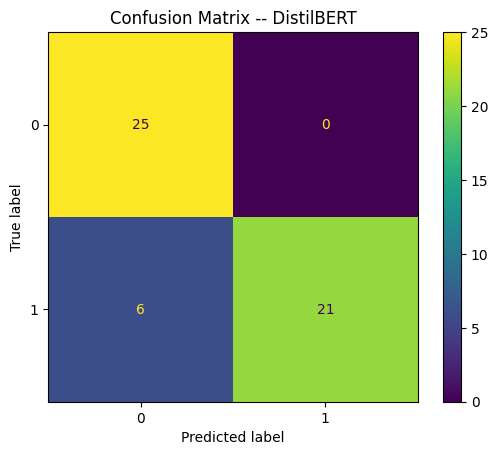


Classification Report: 
              precision    recall  f1-score   support

           0       0.81      1.00      0.89        25
           1       1.00      0.78      0.88        27

    accuracy                           0.88        52
   macro avg       0.90      0.89      0.88        52
weighted avg       0.91      0.88      0.88        52



In [15]:
model.load_state_dict(torch.load(model_path, map_location=device))
model.to(device)

test_loss, test_accuracy, test_f1, y_true, y_pred = evaluate_model(model, test_loader, device)

print("Final Test Loss:", round(test_loss, 4))
print("Final Test Accuracy:", round(test_accuracy, 4))
print("Final Test F1-score:", round(test_f1, 4))

cm = confusion_matrix(y_true, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()

plt.title("Confusion Matrix -- DistilBERT")
plt.show()

print("\nClassification Report: ")
print(classification_report(y_true, y_pred))

In [16]:
print(classification_report(y_true, y_pred, digits=4))

              precision    recall  f1-score   support

           0     0.8065    1.0000    0.8929        25
           1     1.0000    0.7778    0.8750        27

    accuracy                         0.8846        52
   macro avg     0.9032    0.8889    0.8839        52
weighted avg     0.9069    0.8846    0.8836        52



In [17]:
results_table = pd.DataFrame({
    "Model": ["DistilBERT"],
    "Accuracy": [test_accuracy],
    "F1-score": [test_f1]
})

results_table

,Model,Accuracy,F1-score
0,DistilBERT,0.884615,0.875


In [18]:
results_table.to_csv("bert_results_table.csv", index=False)
print("Saved bert_results_table.csv")

Saved bert_results_table.csv
